In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder


from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,precision_score,f1_score,accuracy_score,ConfusionMatrixDisplay,classification_report

In [2]:
df=pd.read_csv('Iris.csv')

In [3]:
df.shape

(150, 6)

In [4]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [9]:
df=df.drop(columns=["Id"])

In [10]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [12]:
le=LabelEncoder()
df["Species"]=le.fit_transform(df["Species"])

In [13]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

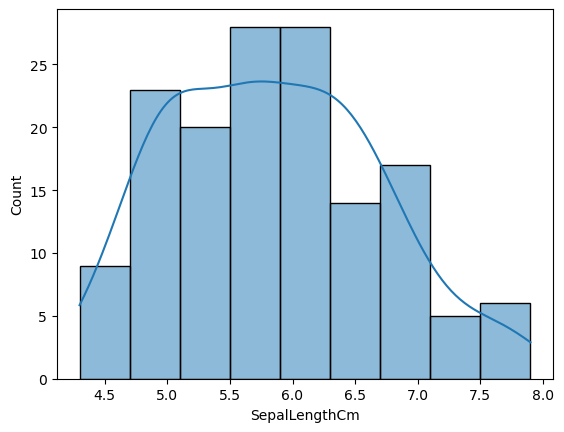

In [14]:
sns.histplot(data=df,x=df["SepalLengthCm"],kde=True)
plt.show()

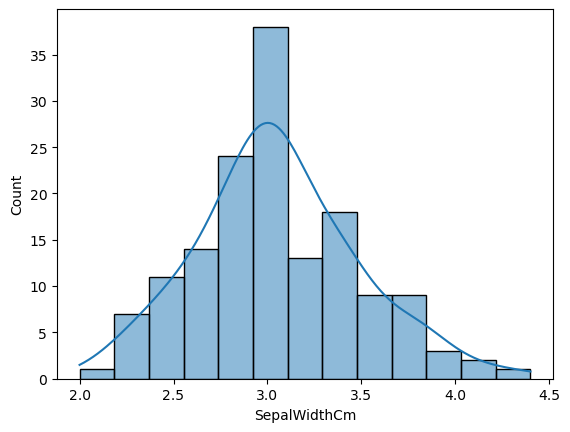

In [15]:
sns.histplot(data=df,x=df["SepalWidthCm"],kde=True)
plt.show()

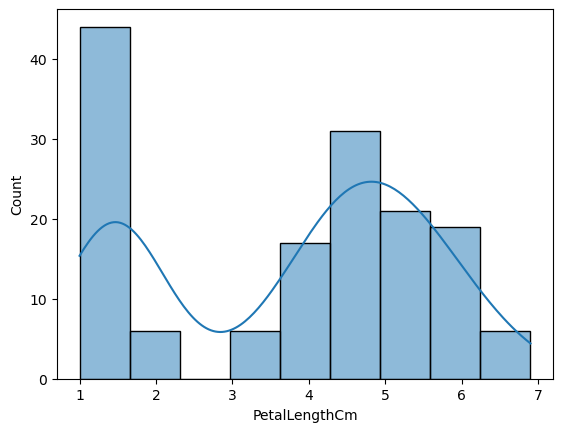

In [16]:
sns.histplot(data=df,x=df["PetalLengthCm"],kde=True)
plt.show()

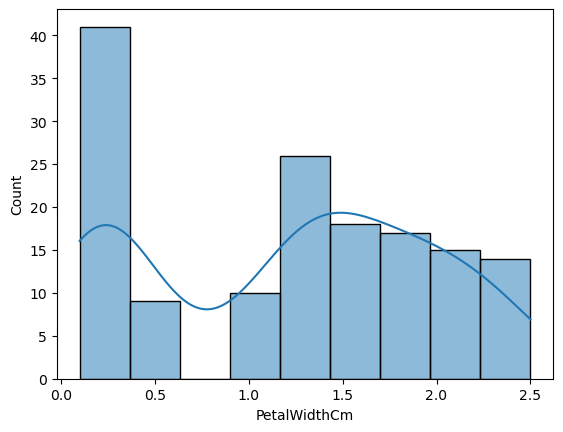

In [17]:
sns.histplot(data=df,x=df["PetalWidthCm"],kde=True)
plt.show()

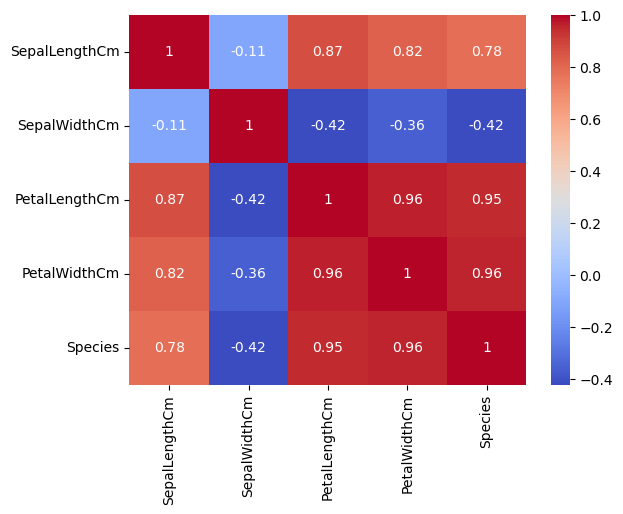

In [18]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

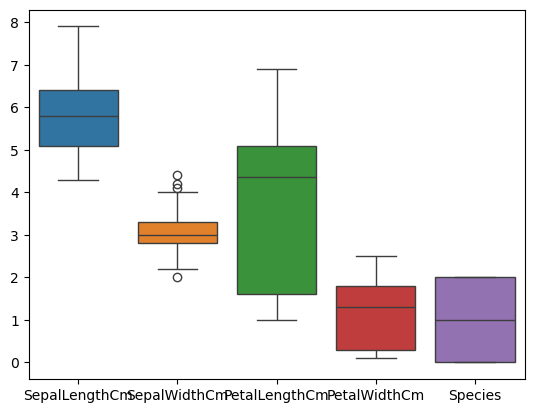

In [19]:
sns.boxplot(data=df)
plt.show()

In [20]:
q1=df["SepalWidthCm"].quantile(0.25)
q3=df["SepalWidthCm"].quantile(0.75)

IQR=q3-q1

lowerbound=q1-1.5*IQR
upperbound=q3+1.5*IQR

df["SepalWidthCm"]=df["SepalWidthCm"].where(df["SepalWidthCm"]>lowerbound,lowerbound)
df["SepalWidthCm"]=df["SepalWidthCm"].where(df["SepalWidthCm"]<upperbound,upperbound)

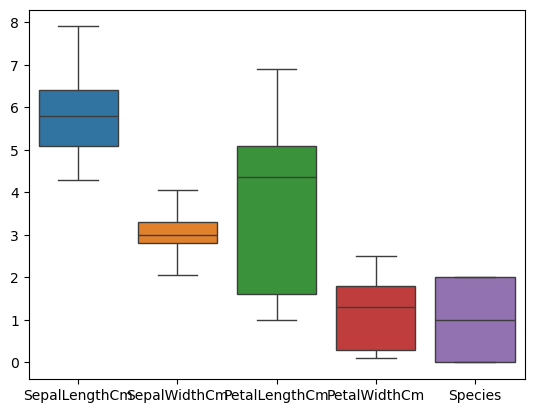

In [21]:
sns.boxplot(data=df)
plt.show()

In [22]:
x=df.drop(columns=["Species"])
y=df["Species"]

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [25]:
model=GaussianNB()

In [26]:
model.fit(x_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [27]:
pred=model.predict(x_test_scaled)

In [28]:
cm=confusion_matrix(y_test,pred)

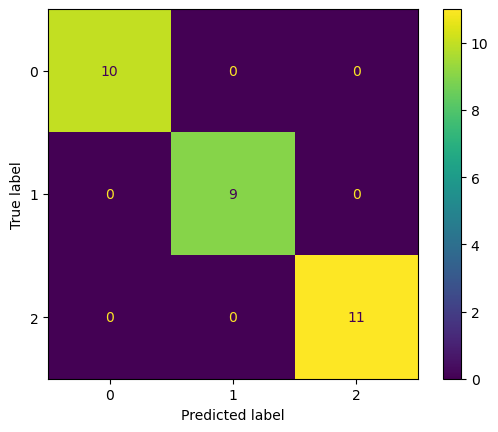

In [29]:
display=ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()

In [30]:
accuracy_score(y_test,pred)

1.0

In [31]:
TP = cm[0][0]
FP = cm[1][0] + cm[2][0]
FN = cm[0][1] + cm[0][2]
TN = cm[1][1] + cm[1][2] + cm[2][1] + cm[2][2]

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("For Setosa Class:\n")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

print("\nAccuracy:",accuracy)
print("Error Rate:",error_rate)
print("Precision:",precision)
print("Recall:",recall)

For Setosa Class:

TP: 10
FP: 0
TN: 20
FN: 0

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


In [32]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

